# Exploratory Data Analysis 

### Imports 

In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: C:\Users\teMelkishi\Desktop\eda


In [2]:
from src.data_loader import load_data

from src.preprocessing import (
    df_summary,
    validate_datatypes,
    analyze_distribution,
    get_categorical_cols,
    get_numerical_cols,
    plot_numerical_distributions,
    plot_numerical_boxplots,
    plot_categorical_distributions,
    correlation_analysis,
    outlier_detection_boxplot
)

In [ ]:
# Load the data
df = load_data(file_path="../data/processed/data.csv")
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,False
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,False
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,False
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,False
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,False


In [4]:
validate_datatypes(df)

,Column,Actual Type,Expected Type,Status
0,TransactionId,str,str,✅ Correct
1,BatchId,str,str,✅ Correct
2,AccountId,str,str,✅ Correct
3,SubscriptionId,str,str,✅ Correct
4,CustomerId,str,str,✅ Correct
5,CurrencyCode,category,category,✅ Correct
6,CountryCode,category,category,✅ Correct
7,ProviderId,category,category,✅ Correct
8,ProductId,category,category,✅ Correct
9,ProductCategory,category,category,✅ Correct


### **Overview of the Data**

Overview of the Data:
    Understand the structure of the dataset, including the number of rows, columns, and data types.
Summary Statistics
    Understand the central tendency, dispersion, and shape of the dataset’s distribution.
Distribution of Numerical Features
    Visualize the distribution of numerical features to identify patterns, skewness, and potential outliers.
Distribution of Categorical Features
    Analyzing the distribution of categorical features provides insights into the frequency and variability of categories.
Correlation Analysis
    Understanding the relationship between numerical features.
Identifying Missing Values
    Identify missing values to determine missing data and decide on appropriate imputation strategies.
Outlier Detection
    Use box plots to identify outliers.

In [5]:
df_summary(df)

--- DATASET OVERVIEW ---
Dimensions: 95662 rows, 16 columns

--- Column Data Types ---
TransactionId                           str
BatchId                                 str
AccountId                               str
SubscriptionId                          str
CustomerId                              str
CurrencyCode                       category
CountryCode                        category
ProviderId                         category
ProductId                          category
ProductCategory                    category
ChannelId                          category
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[us, UTC]
PricingStrategy                    category
FraudResult                            bool
dtype: object

--- Column Information ---
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype              
---  -

### **Summary Statistics**

In [6]:
analyze_distribution(df)

--- DISTRIBUTION ANALYSIS ---


,Amount,Value
Mean,6.717846e+03,9.900584e+03
Median,1.000000e+03,1.000000e+03
Mode,1.000000e+03,1.000000e+03
Std Dev,1.233068e+05,1.231221e+05
Variance,1.520457e+10,1.515905e+10
Range,1.088000e+07,9.879998e+06
IQR,2.850000e+03,4.725000e+03
Skewness,5.109849e+01,5.129109e+01
Kurtosis,3.363128e+03,3.378069e+03


### **Distribution of Numerical Features**

In [7]:
categorical_cols = get_categorical_cols(df)
numerical_cols = get_numerical_cols(df)

In [8]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,False
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,False
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,False
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,False
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,False


c:\Users\teMelkishi\Desktop\eda\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


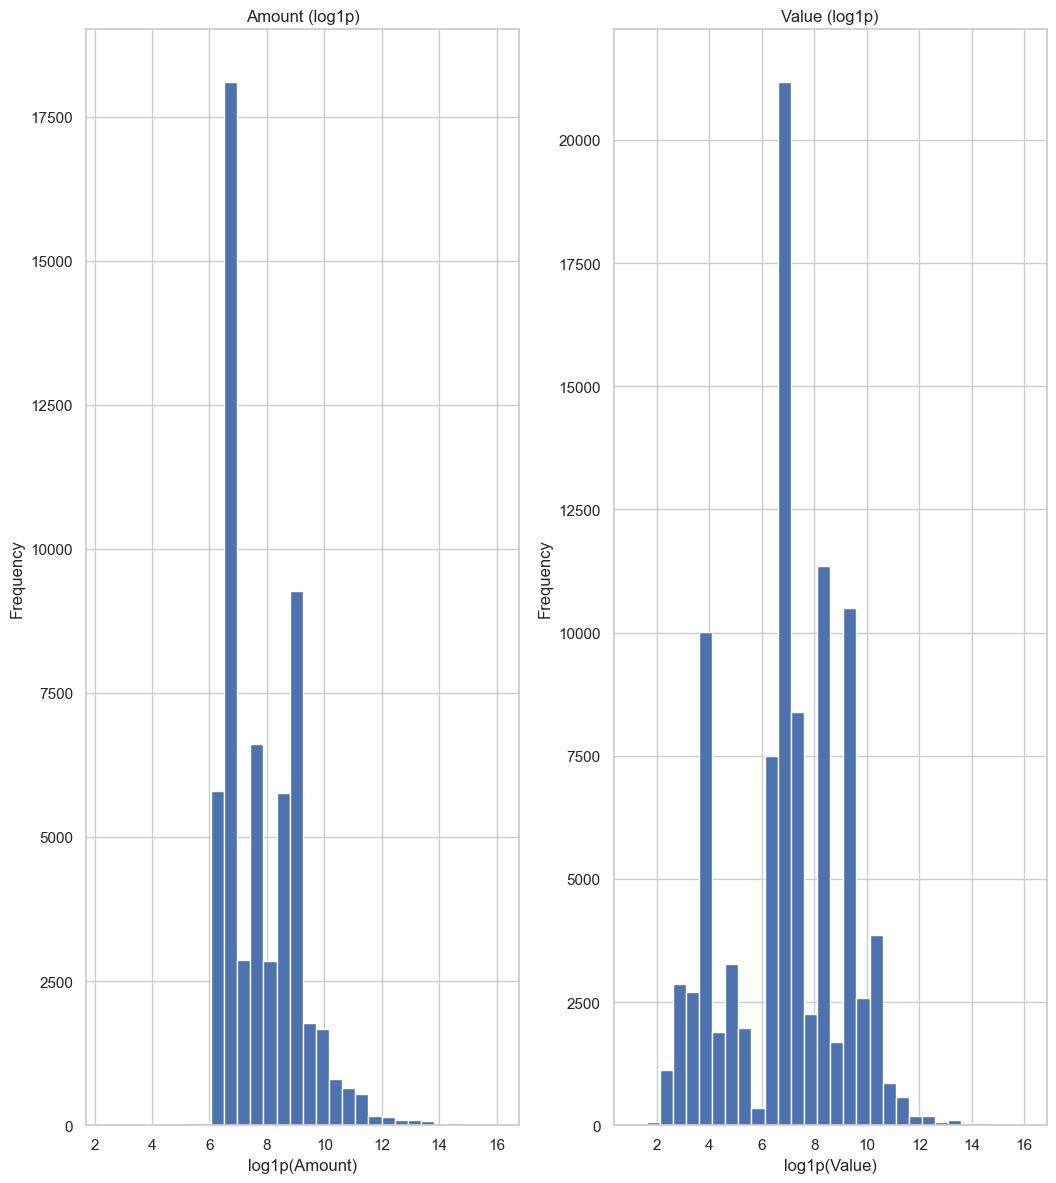

In [9]:
plot_numerical_distributions(df, numerical_cols=numerical_cols, figsize=(16, 12), bins=30, apply_log=True)

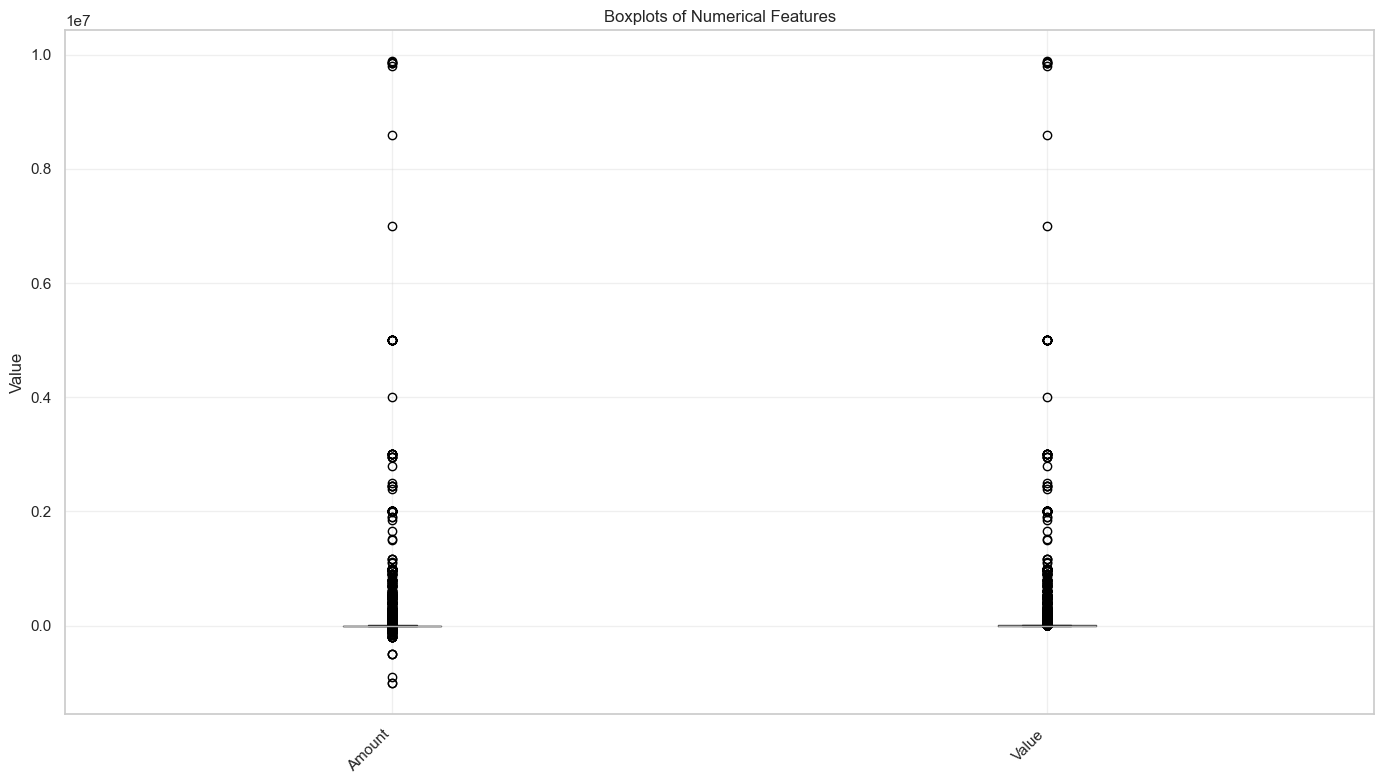

In [10]:
plot_numerical_boxplots(df, numerical_cols=numerical_cols, figsize=(14, 8))

### **Distribution of Categorical Features**

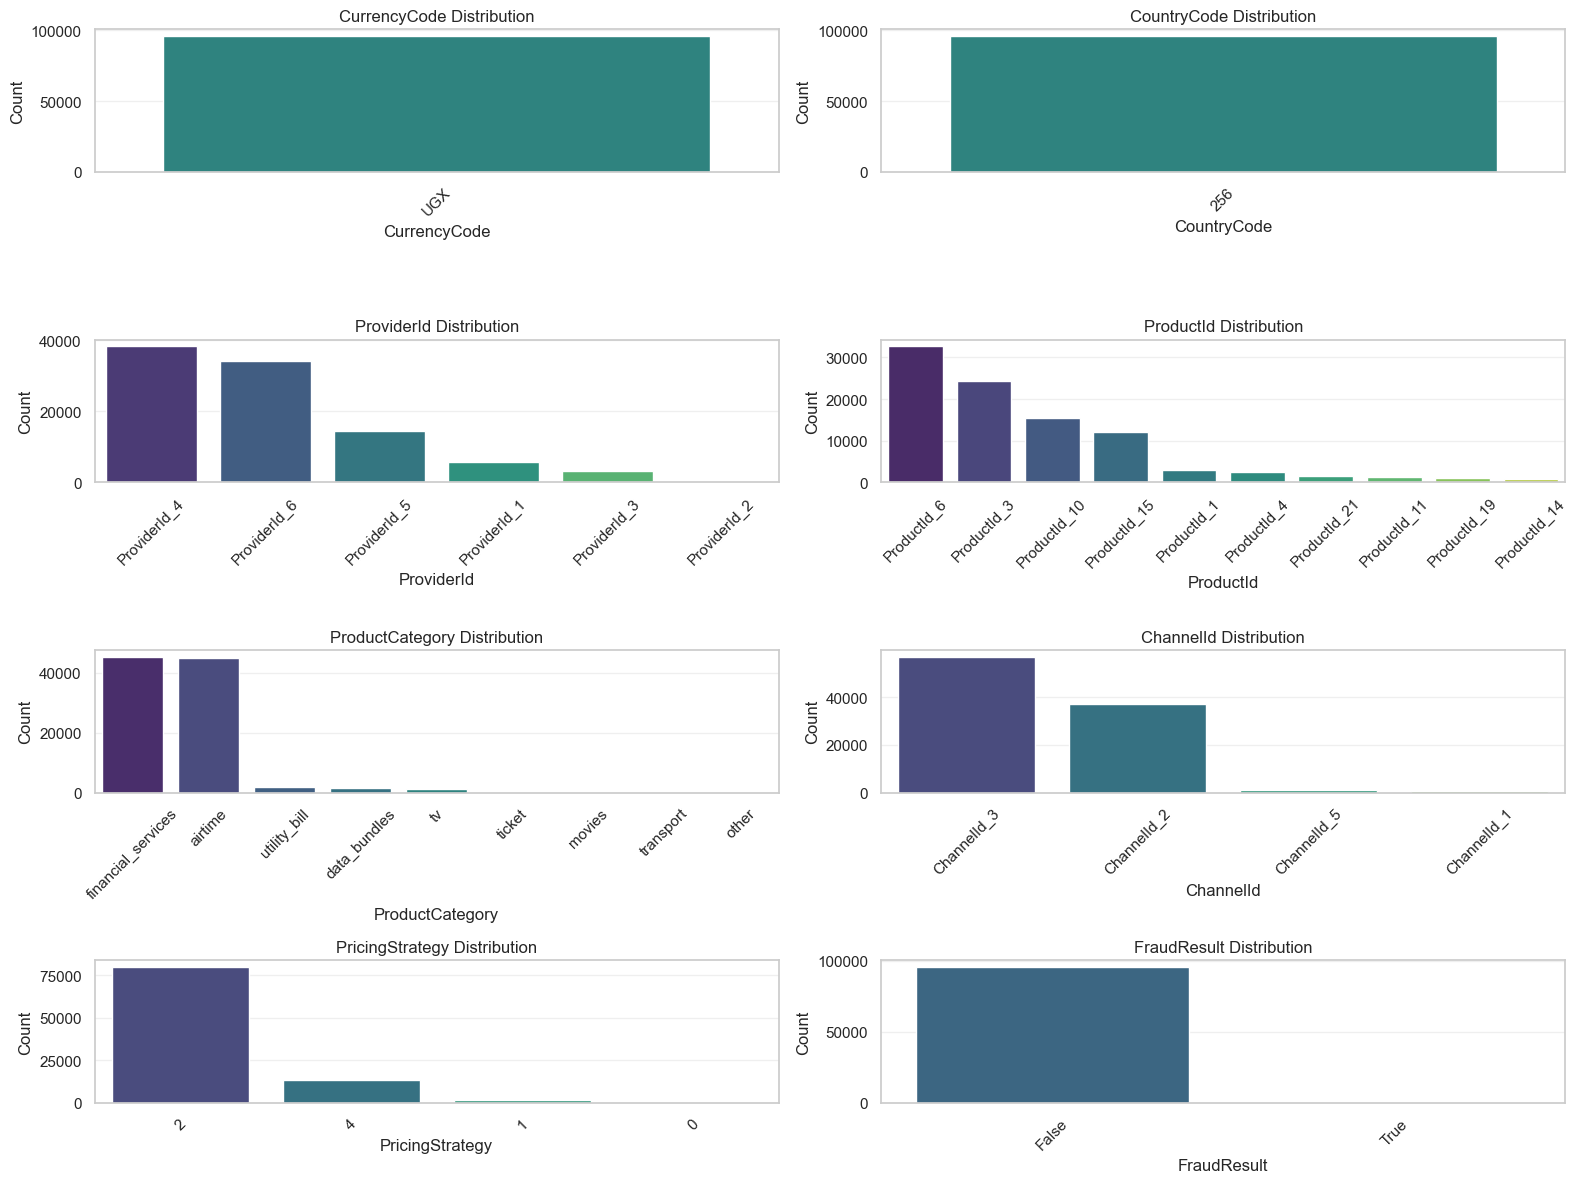

In [11]:
plot_categorical_distributions(df, categorical_cols=categorical_cols, figsize=(16, 12), max_categories=10)

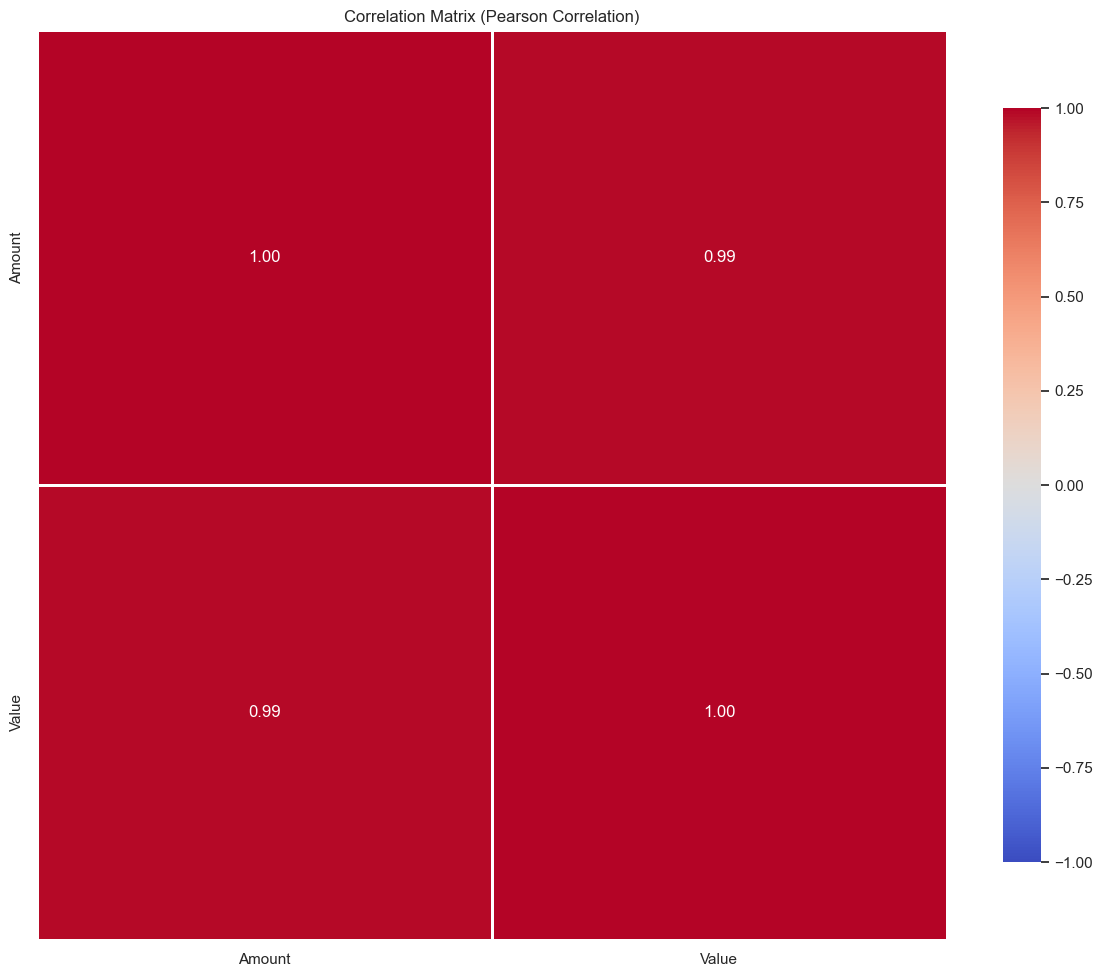

,Amount,Value
Amount,1.000000,0.989692
Value,0.989692,1.000000


In [12]:
correlation_analysis(df, numerical_cols=numerical_cols, figsize=(12, 10))

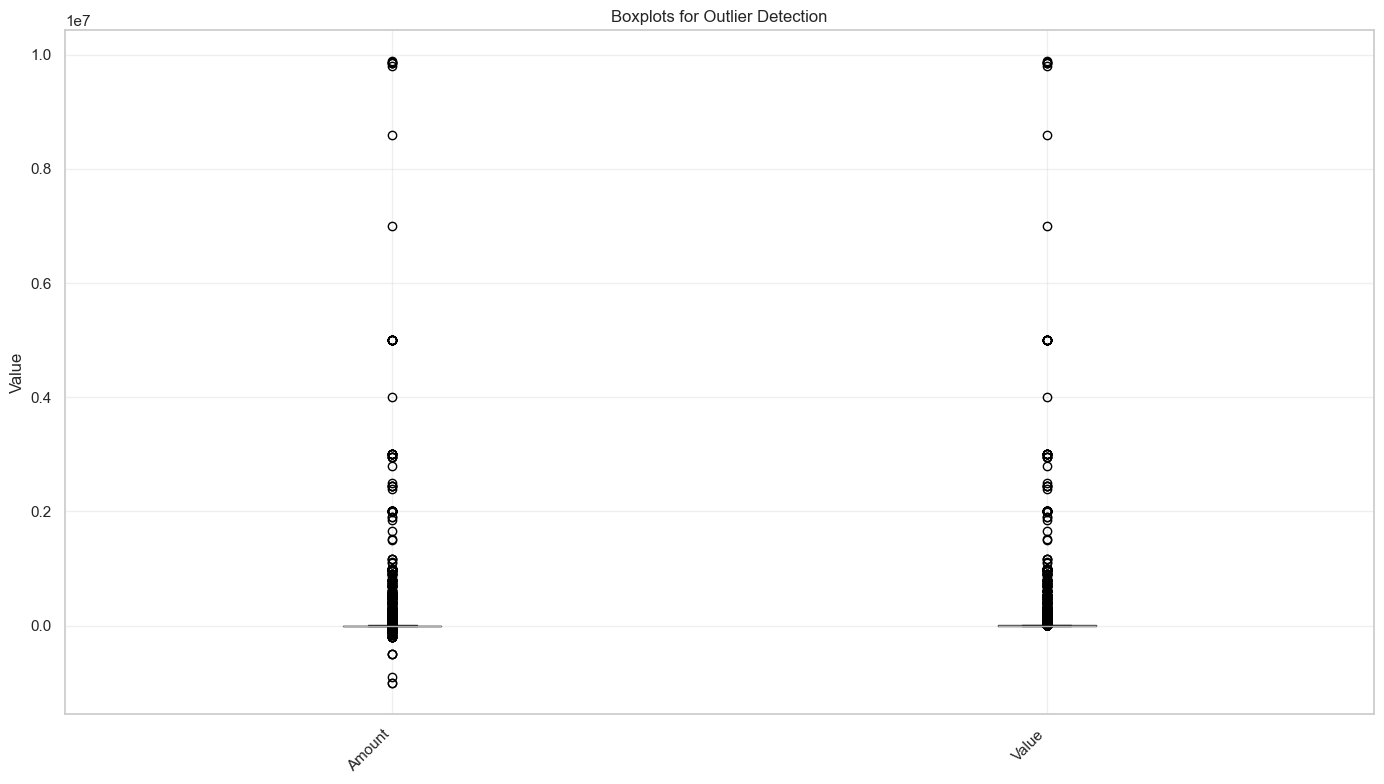

,column,outlier_count,outlier_percent,lower_bound,upper_bound
0,Amount,24441,25.549330,-4325.0,7075.0
1,Value,9021,9.430077,-6812.5,12087.5


In [13]:
outlier_detection_boxplot(df, figsize=(14, 8))